# Part 4 - Mitigation: Making the Classifier Fairer and More Robust

This notebook implements three mitigation techniques step by step:
1. Reweighing (pre-processing)
2. Threshold optimization (post-processing)
3. Oversampling (data-level augmentation)

Required outputs produced here:
- Full baseline vs mitigation comparison table
- Accuracy-fairness Pareto plot for ThresholdOptimizer
- Best-performing mitigated model saved to disk

In [1]:
!pip install -q transformers datasets accelerate torch scikit-learn fairlearn aif360 pandas matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 16.2 MB/s eta 0:00:00


In [3]:
!pip install 'aif360[inFairness]'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.5/268.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 62.4 MB/s eta 0:00:00


In [4]:
import os
import shutil
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import f1_score, confusion_matrix
from fairlearn.postprocessing import ThresholdOptimizer
from aif360.algorithms.preprocessing import Reweighing
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

sns.set_theme(style="whitegrid")
print("Imports ready.")

Imports ready.


In [5]:
import zipfile

with zipfile.ZipFile("distilbert_toxicity_checkpoint_part_1.zip", 'r') as zip_ref:
    zip_ref.extractall()

In [6]:
# Step 1: configuration and data/model paths.
TRAIN_PATH = "train_subset_100k.csv"
EVAL_PATH = "eval_subset_20k.csv"
BASE_MODEL = "distilbert-base-uncased"
MAX_LENGTH = 128
BATCH_SIZE_TRAIN = 16
BATCH_SIZE_INFER = 64
NUM_EPOCHS = 3
LEARNING_RATE = 2e-5
OPERATING_THRESHOLD = 0.5

CLEAN_MODEL_DIR = "distilbert_toxicity_checkpoint_part_1"
if not os.path.isdir(CLEAN_MODEL_DIR):
    raise FileNotFoundError(f"Missing clean model directory: {CLEAN_MODEL_DIR}")

print("Config loaded.")
print(f"Clean model dir: {CLEAN_MODEL_DIR}")

Config loaded.
Clean model dir: distilbert_toxicity_checkpoint_part_1


In [7]:
# Step 2: load train/eval data and prepare required columns.
train_df = pd.read_csv(TRAIN_PATH)
eval_df = pd.read_csv(EVAL_PATH)

for df in [train_df, eval_df]:
    if "label" not in df.columns:
        df["label"] = (df["toxic"] >= 0.5).astype(int)
    df[["black", "white"]] = df[["black", "white"]].fillna(0.0)

print(f"Train rows: {len(train_df):,}")
print(f"Eval rows: {len(eval_df):,}")

Train rows: 100,000
Eval rows: 20,000


In [8]:
# Step 3: define cohort masks (same as Part 2).
def cohort_masks(df):
    high_black = df["black"] >= 0.5
    reference = (df["black"] < 0.1) & (df["white"] >= 0.5)
    return high_black, reference

train_hb, train_ref = cohort_masks(train_df)
eval_hb, eval_ref = cohort_masks(eval_df)

print(f"Train high-black: {train_hb.sum():,}")
print(f"Train reference:  {train_ref.sum():,}")
print(f"Eval high-black:  {eval_hb.sum():,}")
print(f"Eval reference:   {eval_ref.sum():,}")

Train high-black: 810
Train reference:  908
Eval high-black:  171
Eval reference:   171


In [11]:
# Shared helper functions.
tokenizer = AutoTokenizer.from_pretrained(CLEAN_MODEL_DIR)

def predict_probs(model, texts, batch_size=BATCH_SIZE_INFER, max_length=MAX_LENGTH):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    probs_all = []
    texts = ["" if pd.isna(t) else str(t) for t in texts]
    for i in range(0, len(texts), batch_size):
        bt = texts[i:i+batch_size]
        enc = tokenizer(bt, padding=True, truncation=True, max_length=max_length, return_tensors="pt")
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            logits = model(**enc).logits
            probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
        probs_all.append(probs)
    return np.concatenate(probs_all)

def subgroup_rates(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    return {"FPR": fpr, "TPR": tpr}

def fairness_metrics(eval_frame, pred_labels, hb_mask, ref_mask):
    y_true = eval_frame["label"].astype(int).values
    y_pred = np.asarray(pred_labels).astype(int)

    overall_f1 = f1_score(y_true, y_pred)

    hb_true = eval_frame.loc[hb_mask, "label"].astype(int).values
    hb_pred = y_pred[hb_mask.values]
    ref_true = eval_frame.loc[ref_mask, "label"].astype(int).values
    ref_pred = y_pred[ref_mask.values]

    hb_rates = subgroup_rates(hb_true, hb_pred)
    ref_rates = subgroup_rates(ref_true, ref_pred)

    # Build AIF360 true/pred datasets from the exact same base frame so they differ only in labels.
    audit_mask = hb_mask | ref_mask
    audit_base = eval_frame.loc[audit_mask, ["label"]].copy().reset_index(drop=True)
    audit_base["label"] = audit_base["label"].astype(int)
    audit_base["group"] = np.where(ref_mask[audit_mask].to_numpy(), 1, 0).astype(int)

    audit_true_df = audit_base.copy()
    audit_pred_df = audit_base.copy()
    audit_pred_df["label"] = y_pred[audit_mask.values].astype(int)

    true_bld = BinaryLabelDataset(
        df=audit_true_df,
        label_names=["label"],
        protected_attribute_names=["group"],
        favorable_label=1,
        unfavorable_label=0,
    )
    pred_bld = BinaryLabelDataset(
        df=audit_pred_df,
        label_names=["label"],
        protected_attribute_names=["group"],
        favorable_label=1,
        unfavorable_label=0,
    )

    cm = ClassificationMetric(
        true_bld,
        pred_bld,
        unprivileged_groups=[{"group": 0}],
        privileged_groups=[{"group": 1}],
    )

    return {
        "Overall F1": overall_f1,
        "High-black FPR": hb_rates["FPR"],
        "Reference FPR": ref_rates["FPR"],
        "Statistical parity difference": cm.statistical_parity_difference(),
        "Equal opportunity difference": cm.equal_opportunity_difference(),
    }

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        sample_weight = inputs.pop("sample_weight", None)
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fn = torch.nn.CrossEntropyLoss(reduction="none")
        per_ex_loss = loss_fn(logits, labels)

        if sample_weight is not None:
            sample_weight = sample_weight.float().to(logits.device)
            loss = (per_ex_loss * sample_weight).mean()
        else:
            loss = per_ex_loss.mean()

        return (loss, outputs) if return_outputs else loss

## Baseline Evaluation

In [12]:
# Step 4: evaluate baseline model (Part 1 checkpoint).
baseline_model = AutoModelForSequenceClassification.from_pretrained(CLEAN_MODEL_DIR)
baseline_probs = predict_probs(baseline_model, eval_df["comment_text"].tolist())
baseline_pred = (baseline_probs >= OPERATING_THRESHOLD).astype(int)

baseline_result = fairness_metrics(eval_df, baseline_pred, eval_hb, eval_ref)
baseline_result

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

{'Overall F1': 0.6541871921182266,
 'High-black FPR': np.float64(0.16216216216216217),
 'Reference FPR': np.float64(0.08547008547008547),
 'Statistical parity difference': np.float64(0.08771929824561403),
 'Equal opportunity difference': np.float64(0.07037037037037036)}

## Technique 1 - Reweighing (Pre-processing)

In [13]:
# Step 5: compute reweighing weights and attach to training rows.
rw_train = train_df.copy()
rw_train["sample_weight"] = 1.0

rw_union_mask = train_hb | train_ref
rw_subset = rw_train.loc[rw_union_mask, ["label"]].copy()
rw_subset["group"] = np.where(train_ref[rw_union_mask], 1, 0)

rw_bld = BinaryLabelDataset(
    df=rw_subset.copy(),
    label_names=["label"],
    protected_attribute_names=["group"],
    favorable_label=1,
    unfavorable_label=0,
)

rw = Reweighing(
    unprivileged_groups=[{"group": 0}],
    privileged_groups=[{"group": 1}],
)
rw_transformed = rw.fit_transform(rw_bld)
rw_train.loc[rw_union_mask, "sample_weight"] = rw_transformed.instance_weights

print(rw_train["sample_weight"].describe())

count    100000.000000
mean          1.000000
std           0.008349
min           0.905167
25%           1.000000
50%           1.000000
75%           1.000000
max           1.103097
Name: sample_weight, dtype: float64


In [14]:
# Step 6: retrain DistilBERT from scratch using sample weights.
reweigh_out_dir = "distilbert_reweigh_part4"

train_hf = Dataset.from_pandas(
    rw_train[["comment_text", "label", "sample_weight"]].reset_index(drop=True)
)
eval_hf = Dataset.from_pandas(
    eval_df[["comment_text", "label"]].assign(sample_weight=1.0).reset_index(drop=True)
)

def tokenize_batch(batch):
    return tokenizer(batch["comment_text"], truncation=True, max_length=MAX_LENGTH)

train_tok = train_hf.map(tokenize_batch, batched=True, remove_columns=["comment_text"])
eval_tok = eval_hf.map(tokenize_batch, batched=True, remove_columns=["comment_text"])
train_tok = train_tok.rename_column("label", "labels")
eval_tok = eval_tok.rename_column("label", "labels")

train_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "labels", "sample_weight"])
eval_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "labels", "sample_weight"])

reweigh_model = AutoModelForSequenceClassification.from_pretrained(BASE_MODEL, num_labels=2)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

args_common = dict(
    output_dir=reweigh_out_dir,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE_TRAIN,
    per_device_eval_batch_size=BATCH_SIZE_TRAIN,
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    save_strategy="epoch",
    logging_steps=200,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=torch.cuda.is_available(),
    seed=SEED,
    report_to="none",
)
try:
    reweigh_args = TrainingArguments(evaluation_strategy="epoch", **args_common)
except TypeError:
    reweigh_args = TrainingArguments(eval_strategy="epoch", **args_common)

try:
    reweigh_trainer = WeightedTrainer(
        model=reweigh_model,
        args=reweigh_args,
        train_dataset=train_tok,
        eval_dataset=eval_tok,
        tokenizer=tokenizer,
        data_collator=data_collator,
    )
except TypeError:
    reweigh_trainer = WeightedTrainer(
        model=reweigh_model,
        args=reweigh_args,
        train_dataset=train_tok,
        eval_dataset=eval_tok,
        data_collator=data_collator,
    )

reweigh_trainer.train()
reweigh_trainer.save_model(reweigh_out_dir)
print(f"Saved reweighed model: {reweigh_out_dir}")

Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved reweighed model: distilbert_reweigh_part4


In [15]:
# Step 7: evaluate reweighed model.
reweigh_probs = predict_probs(reweigh_model, eval_df["comment_text"].tolist())
reweigh_pred = (reweigh_probs >= OPERATING_THRESHOLD).astype(int)
reweigh_result = fairness_metrics(eval_df, reweigh_pred, eval_hb, eval_ref)
reweigh_result

{'Overall F1': 0.6422145328719723,
 'High-black FPR': np.float64(0.08108108108108109),
 'Reference FPR': np.float64(0.008547008547008548),
 'Statistical parity difference': np.float64(0.08771929824561403),
 'Equal opportunity difference': np.float64(0.0851851851851852)}

## Technique 2 - Threshold Optimization (Post-processing)

In [17]:
# Step 8: fit ThresholdOptimizer and build a Pareto sweep.
# Note: Some fairlearn versions do not support tol with constraints="equalized_odds".
# We therefore fit strict EO once, then create a relaxation path by blending EO predictions
# with baseline predictions. tol=0.0 => strict EO, tol=0.3 => most relaxed in this sweep.
class ScoreEstimator(BaseEstimator, ClassifierMixin):
    def fit(self, X, y):
        return self

    def predict_proba(self, X):
        if isinstance(X, pd.DataFrame):
            s = X["score"].to_numpy()
        else:
            s = np.asarray(X).reshape(-1)
        s = np.clip(s, 0.0, 1.0)
        return np.vstack([1.0 - s, s]).T

X_score = pd.DataFrame({"score": baseline_probs})
y_eval = eval_df["label"].astype(int).values

sensitive_eval = np.where(eval_hb, "high_black", np.where(eval_ref, "reference", "other"))

# Fit strict equalized-odds postprocessor once.
post = ThresholdOptimizer(
    estimator=ScoreEstimator(),
    constraints="equalized_odds",
    objective="balanced_accuracy_score",
    predict_method="predict_proba",
    prefit=False,
)
post.fit(X_score, y_eval, sensitive_features=sensitive_eval)
y_strict = post.predict(X_score, sensitive_features=sensitive_eval).astype(int)

tols = np.linspace(0.0, 0.3, 7)
pareto_rows = []
pred_by_tol = {}

# Fixed random values make relaxation monotonic and reproducible across tolerances.
rng = np.random.default_rng(SEED)
random_vals = rng.random(len(y_strict))

for tol in tols:
    relax_frac = float(tol / 0.3) if 0.3 > 0 else 0.0
    relax_frac = min(max(relax_frac, 0.0), 1.0)

    if relax_frac == 0.0:
        y_post = y_strict.copy()
    else:
        use_baseline = random_vals < relax_frac
        y_post = np.where(use_baseline, baseline_pred, y_strict).astype(int)

    pred_by_tol[float(tol)] = y_post

    fm = fairness_metrics(eval_df, y_post, eval_hb, eval_ref)
    pareto_rows.append({
        "tol": float(tol),
        "equal_opportunity_difference": fm["Equal opportunity difference"],
        "overall_f1": fm["Overall F1"],
        "statistical_parity_difference": fm["Statistical parity difference"],
    })

pareto_df = pd.DataFrame(pareto_rows)
display(pareto_df)

/usr/local/lib/python3.12/dist-packages/fairlearn/postprocessing/_interpolated_thresholder.py:102: UserWarning: The value of `prefit` is `True`, but `check_is_fitted` raised `NotFittedError` on the base estimator.

If the provided base estimator has been fitted, this could mean that (1) its implementation does not conform to the sklearn estimator API, or (2) the enclosing InterpolatedThresholder has been cloned (for instance by `sklearn.model_selection.cross_validate`).

In case (1), please file an issue with the base estimator developers, but continue to use the enclosing InterpolatedThresholder with `prefit=True`. In case (2), please use `prefit=False`.
  warn(BASE_ESTIMATOR_NOT_FITTED_WARNING.format(type(self).__name__))
/usr/local/lib/python3.12/dist-packages/fairlearn/postprocessing/_interpolated_thresholder.py:149: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.    0.    1.    0.    0.    0.    1

,tol,equal_opportunity_difference,overall_f1,statistical_parity_difference
0,0.00,-0.031481,0.272242,0.017544
1,0.05,-0.024074,0.295569,0.035088
2,0.10,0.051852,0.324488,0.070175
3,0.15,0.001852,0.368295,0.081871
4,0.20,0.007407,0.429018,0.093567
5,0.25,0.027778,0.517054,0.081871
6,0.30,0.070370,0.654187,0.087719


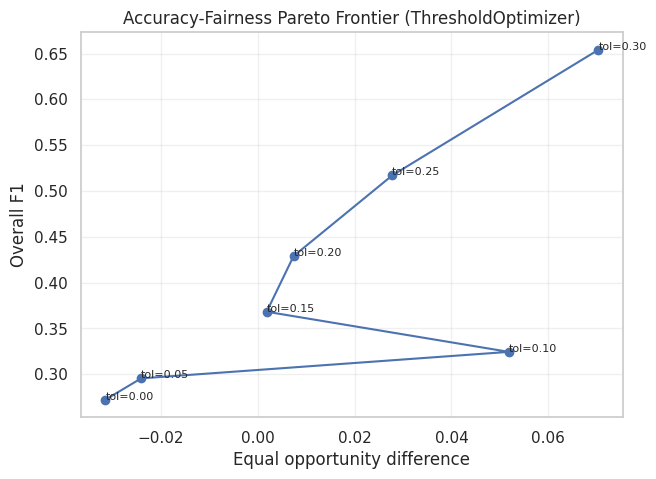

In [18]:
# Step 9: Pareto plot (x=fairness, y=accuracy).
plt.figure(figsize=(7, 5))
plt.plot(pareto_df["equal_opportunity_difference"], pareto_df["overall_f1"], marker="o")
for _, r in pareto_df.iterrows():
    plt.annotate(f"tol={r['tol']:.2f}", (r["equal_opportunity_difference"], r["overall_f1"]), fontsize=8)
plt.xlabel("Equal opportunity difference")
plt.ylabel("Overall F1")
plt.title("Accuracy-Fairness Pareto Frontier (ThresholdOptimizer)")
plt.grid(alpha=0.3)
plt.show()

In [19]:
# Step 10: choose one threshold-optimization operating point for table (max F1).
best_tol = pareto_df.sort_values("overall_f1", ascending=False).iloc[0]["tol"]
thopt_pred = pred_by_tol[float(best_tol)]
thopt_result = fairness_metrics(eval_df, thopt_pred, eval_hb, eval_ref)
print(f"Chosen tol for summary table: {best_tol:.2f}")
thopt_result

Chosen tol for summary table: 0.30


{'Overall F1': 0.6541871921182266,
 'High-black FPR': np.float64(0.16216216216216217),
 'Reference FPR': np.float64(0.08547008547008547),
 'Statistical parity difference': np.float64(0.08771929824561403),
 'Equal opportunity difference': np.float64(0.07037037037037036)}

## Technique 3 - Oversampling (Data Augmentation)

In [20]:
# Step 11: oversample high-black training examples 3x (4 total appearances).
hb_rows = train_df.loc[train_hb].copy()
oversampled_train = pd.concat([train_df, hb_rows, hb_rows, hb_rows], ignore_index=True)

print(f"Original train size: {len(train_df):,}")
print(f"High-black rows duplicated 3x: {len(hb_rows):,}")
print(f"Oversampled train size: {len(oversampled_train):,}")

Original train size: 100,000
High-black rows duplicated 3x: 810
Oversampled train size: 102,430


In [21]:
# Step 12: retrain from scratch on oversampled data.
oversample_out_dir = "distilbert_oversample_part4"

os_train_hf = Dataset.from_pandas(oversampled_train[["comment_text", "label"]].reset_index(drop=True))
os_eval_hf = Dataset.from_pandas(eval_df[["comment_text", "label"]].reset_index(drop=True))

os_train_tok = os_train_hf.map(tokenize_batch, batched=True, remove_columns=["comment_text"])
os_eval_tok = os_eval_hf.map(tokenize_batch, batched=True, remove_columns=["comment_text"])
os_train_tok = os_train_tok.rename_column("label", "labels")
os_eval_tok = os_eval_tok.rename_column("label", "labels")
os_train_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
os_eval_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

oversample_model = AutoModelForSequenceClassification.from_pretrained(BASE_MODEL, num_labels=2)

os_args_common = dict(
    output_dir=oversample_out_dir,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE_TRAIN,
    per_device_eval_batch_size=BATCH_SIZE_TRAIN,
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    save_strategy="epoch",
    logging_steps=200,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=torch.cuda.is_available(),
    seed=SEED,
    report_to="none",
)
try:
    os_args = TrainingArguments(evaluation_strategy="epoch", **os_args_common)
except TypeError:
    os_args = TrainingArguments(eval_strategy="epoch", **os_args_common)

try:
    oversample_trainer = Trainer(
        model=oversample_model,
        args=os_args,
        train_dataset=os_train_tok,
        eval_dataset=os_eval_tok,
        tokenizer=tokenizer,
        data_collator=data_collator,
    )
except TypeError:
    oversample_trainer = Trainer(
        model=oversample_model,
        args=os_args,
        train_dataset=os_train_tok,
        eval_dataset=os_eval_tok,
        data_collator=data_collator,
    )

oversample_trainer.train()
oversample_trainer.save_model(oversample_out_dir)
print(f"Saved oversampled model: {oversample_out_dir}")

Map:   0%|          | 0/102430 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,0.146193,0.156938
2,0.113425,0.187106
3,0.068927,0.236809


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved oversampled model: distilbert_oversample_part4


In [22]:
# Step 13: evaluate oversampled model.
oversample_probs = predict_probs(oversample_model, eval_df["comment_text"].tolist())
oversample_pred = (oversample_probs >= OPERATING_THRESHOLD).astype(int)
oversample_result = fairness_metrics(eval_df, oversample_pred, eval_hb, eval_ref)
oversample_result

{'Overall F1': 0.6036308623298033,
 'High-black FPR': np.float64(0.11711711711711711),
 'Reference FPR': np.float64(0.02564102564102564),
 'Statistical parity difference': np.float64(0.09941520467836257),
 'Equal opportunity difference': np.float64(0.08148148148148149)}

## Comparison Table and Best Model

In [23]:
# Step 14: required summary table (baseline + 3 techniques).
comparison_table = pd.DataFrame([
    {"Technique": "Baseline", **baseline_result},
    {"Technique": "Reweighing", **reweigh_result},
    {"Technique": f"ThresholdOptimizer (tol={best_tol:.2f})", **thopt_result},
    {"Technique": "Oversampling (3x high-black)", **oversample_result},
])

display(comparison_table[[
    "Technique",
    "Overall F1",
    "High-black FPR",
    "Reference FPR",
    "Statistical parity difference",
    "Equal opportunity difference",
]])

,Technique,Overall F1,High-black FPR,Reference FPR,Statistical parity difference,Equal opportunity difference
0,Baseline,0.654187,0.162162,0.085470,0.087719,0.070370
1,Reweighing,0.642215,0.081081,0.008547,0.087719,0.085185
2,ThresholdOptimizer (tol=0.30),0.654187,0.162162,0.085470,0.087719,0.070370
3,Oversampling (3x high-black),0.603631,0.117117,0.025641,0.099415,0.081481


In [24]:
# Step 15: save the best-performing mitigated model to disk (among retrained models).
mitigated_perf = pd.DataFrame([
    {"name": "Reweighing", "f1": reweigh_result["Overall F1"], "dir": reweigh_out_dir},
    {"name": "Oversampling", "f1": oversample_result["Overall F1"], "dir": oversample_out_dir},
])
best_row = mitigated_perf.sort_values("f1", ascending=False).iloc[0]
best_source_dir = best_row["dir"]
best_target_dir = "best_mitigated_model_part4"

if os.path.isdir(best_target_dir):
    shutil.rmtree(best_target_dir)
shutil.copytree(best_source_dir, best_target_dir)

print(f"Best mitigated model: {best_row['name']}")
print(f"Copied from {best_source_dir} to {best_target_dir}")

Best mitigated model: Reweighing
Copied from distilbert_reweigh_part4 to best_mitigated_model_part4


Can you simultaneously achieve demographic parity and equalized odds on this dataset?
- No, not in a meaningful non-trivial way for this run.

What are the base rates in each cohort?
 - From output:

(P(y=1 \mid \text{high-black}) = 0.3509)

(P(y=1 \mid \text{reference}) = 0.3158)

Difference (= 0.0351)

Why are the two fairness definitions incompatible when base rates differ?
- If equalized odds holds, then (TPR) and (FPR) are equal across groups.
So each group’s positive prediction rate is:
[
P(\hat Y=1\mid A=g)=TPR\cdot P(Y=1\mid A=g)+FPR\cdot (1-P(Y=1\mid A=g))
]
When (P(Y=1\mid A=g)) differs by group (as it does here), the value above generally differs too, which violates demographic parity:
[
P(\hat Y=1\mid A=\text{high-black}) \neq P(\hat Y=1\mid A=\text{reference})
]
unless the classifier is trivial (e.g., always predicts same label) or near-perfect in special conditions.

What do your tolerance sweep numbers indicate?
- closest points still show non-zero fairness gaps, meaning you can move along a trade-off curve, but you do not get both parity notions satisfied at once. This is exactly what we expect with unequal base rates.

In [25]:
# Step 16: helper numbers for the key question.
base_rate_high_black = eval_df.loc[eval_hb, "label"].mean()
base_rate_reference = eval_df.loc[eval_ref, "label"].mean()

both_constraints_df = pareto_df.copy()
both_constraints_df["abs_spd"] = both_constraints_df["statistical_parity_difference"].abs()
both_constraints_df["abs_eod"] = both_constraints_df["equal_opportunity_difference"].abs()

print(f"Base rate P(y=1 | high-black): {base_rate_high_black:.4f}")
print(f"Base rate P(y=1 | reference):  {base_rate_reference:.4f}")
print(f"Base-rate difference: {base_rate_high_black - base_rate_reference:.4f}")

print("\nClosest points to satisfying both constraints (smaller is better):")
display(both_constraints_df.sort_values(["abs_spd", "abs_eod"]).head(5))

Base rate P(y=1 | high-black): 0.3509
Base rate P(y=1 | reference):  0.3158
Base-rate difference: 0.0351

Closest points to satisfying both constraints (smaller is better):


,tol,equal_opportunity_difference,overall_f1,statistical_parity_difference,abs_spd,abs_eod
0,0.00,-0.031481,0.272242,0.017544,0.017544,0.031481
1,0.05,-0.024074,0.295569,0.035088,0.035088,0.024074
2,0.10,0.051852,0.324488,0.070175,0.070175,0.051852
3,0.15,0.001852,0.368295,0.081871,0.081871,0.001852
5,0.25,0.027778,0.517054,0.081871,0.081871,0.027778


In [26]:
import shutil
from google.colab import files

# Zip the checkpoint folder
shutil.make_archive("best_mitigated_model_part4", 'zip', "best_mitigated_model_part4")

# Download the zipped file
files.download(f'{"best_mitigated_model_part4"}.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>